In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


In [2]:
df=pd.read_csv("economic_index.csv")


In [3]:
df.shape

(24, 6)

In [4]:
data2=df.copy(deep=True)
data2.head(23)

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256
5,5,2017,7,2.50,5.6,1254
6,6,2017,6,2.50,5.5,1234
7,7,2017,5,2.25,5.5,1195
8,8,2017,4,2.25,5.5,1159
9,9,2017,3,2.25,5.6,1167


In [5]:
data2.drop('Unnamed: 0',axis=1,inplace=True)

In [6]:
data2.head()

,year,month,interest_rate,unemployment_rate,index_price
0,2017,12,2.75,5.3,1464
1,2017,11,2.50,5.3,1394
2,2017,10,2.50,5.3,1357
3,2017,9,2.50,5.3,1293
4,2017,8,2.50,5.4,1256


In [7]:
data2.drop(['year','month'],axis=1,inplace=True)

In [8]:
data2.columns

Index(['interest_rate', 'unemployment_rate', 'index_price'], dtype='object')

In [9]:
data2.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

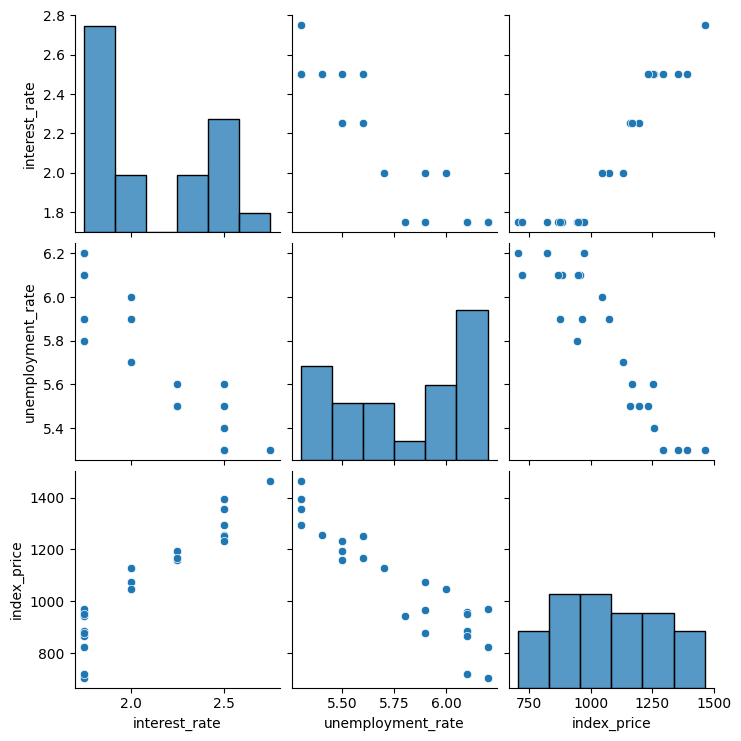

In [10]:
## Lets do visulization
import seaborn as sns
sns.pairplot(data2)

In [11]:
data2.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'unemployment rate')

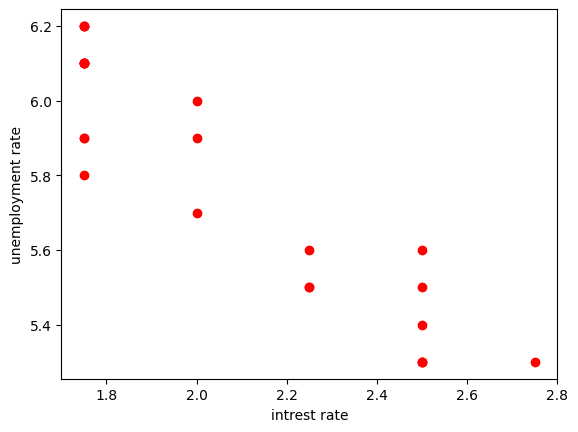

In [12]:
## Visualize the datapoints more closely
plt.scatter(data2['interest_rate'],data2['unemployment_rate'],color='r')
plt.xlabel("intrest rate")
plt.ylabel("unemployment rate")

In [13]:
## Dependent and Undependent feature
X=data2.iloc[:,:-1]
y=data2.iloc[:,-1]

In [14]:
type(X)

pandas.core.frame.DataFrame

In [15]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [16]:
y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

In [17]:
## Train Test Split 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

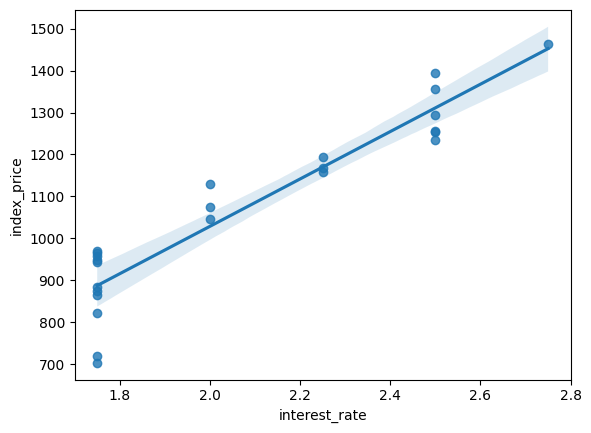

In [18]:
sns.regplot(x='interest_rate', y='index_price', data=data2)   

In [19]:
data2.shape

(24, 3)

In [20]:
data2.head(10)

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256
5,2.50,5.6,1254
6,2.50,5.5,1234
7,2.25,5.5,1195
8,2.25,5.5,1159
9,2.25,5.6,1167


<Axes: xlabel='index_price', ylabel='unemployment_rate'>

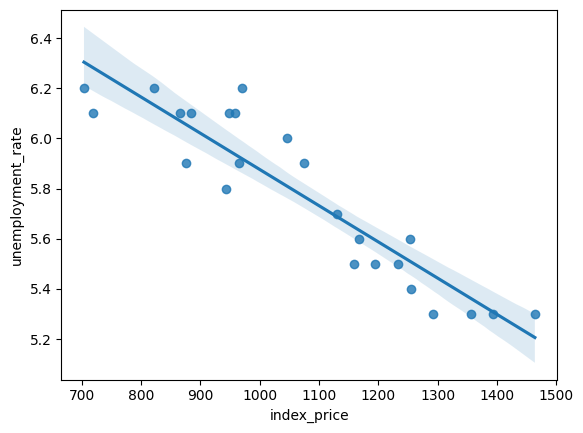

In [21]:
sns.regplot(x='index_price', y='unemployment_rate', data=data2, ci=95, order=1)   

In [22]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [23]:
X_train

array([[ 0.55339859, -0.53244666],
       [-0.9486833 ,  0.41597395],
       [ 1.30443953, -1.48086727],
       [-0.9486833 ,  1.36439457],
       [ 1.30443953, -0.53244666],
       [ 1.30443953, -1.48086727],
       [-0.19764235,  0.73211416],
       [-0.9486833 ,  1.04825436],
       [ 1.30443953, -1.48086727],
       [ 1.30443953, -1.16472707],
       [-0.9486833 ,  1.36439457],
       [-0.9486833 ,  1.04825436],
       [-0.9486833 ,  0.41597395],
       [-0.9486833 ,  1.04825436],
       [ 0.55339859, -0.84858687],
       [-0.19764235, -0.21630646],
       [-0.9486833 ,  0.09983375],
       [-0.9486833 ,  1.04825436],
       [ 1.30443953, -0.84858687]])

In [24]:
from sklearn.linear_model import LinearRegression
linear=LinearRegression()
linear.fit(X_train,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
from sklearn.model_selection import cross_val_score

validation_score=cross_val_score(linear,X_train,y_train,scoring='neg_mean_squared_error',cv=3)
print(validation_score)

[-4304.75412833 -7608.56499271 -5108.77588052]


In [26]:
np.mean(validation_score)

np.float64(-5674.031667186762)

In [27]:
## prediction
y_pred=linear.predict(X_test)

In [28]:
y_pred

array([1204.14403741,  821.62603274, 1406.38534684,  857.68137178,
        994.85736555])

In [29]:
## Performance metric
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)
print(mse)
print(mae)
print(rmse)

6957.105303258833
71.71878409976625
83.40926389351985


In [30]:
## R square metric
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)

0.8254940547158576


In [31]:
## Adjusted R square metric
1-(1-score)*len((y_test)-1)/(len(y_test)-X_test.shape[1]-1)





0.5637351367896439

## Assumptions

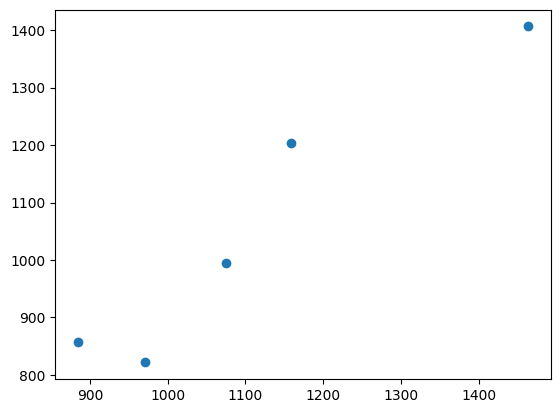

In [32]:
plt.scatter(y_test,y_pred)

In [33]:
residuals=y_test-y_pred
print(residuals)

8     -45.144037
16    149.373967
0      57.614653
18     26.318628
11     80.142634
Name: index_price, dtype: float64


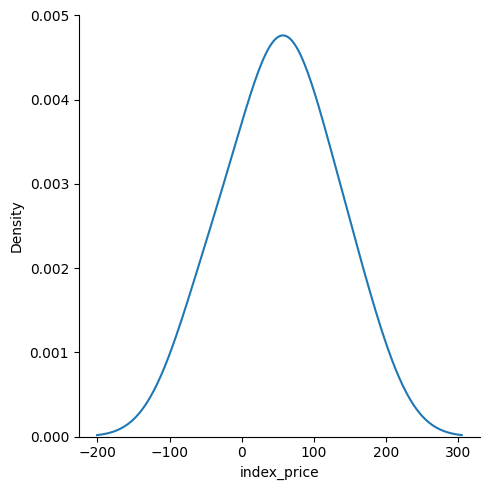

In [34]:
## plot the residuals
sns.displot(residuals,kind='kde')

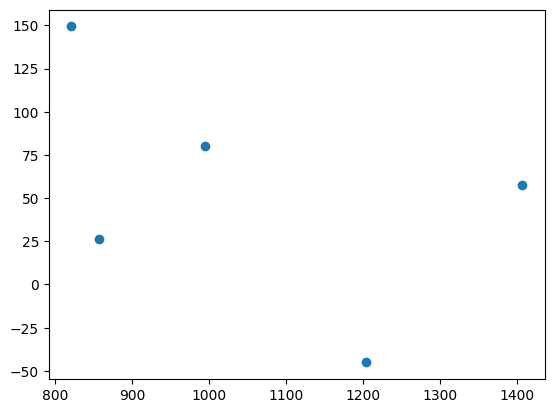

In [35]:
## Scatter plot with respect to prediction and residuals
plt.scatter(y_pred,residuals)

In [36]:
print(linear.coef_)

[  86.63351334 -114.04857249]


In [38]:
## OLS Linear Regression

import statsmodels.api as sm
model=sm.OLS(y_train,X_train).fit()
prediction=model.predict(X_test)
print(prediction)
print(model.summary())

[ 144.72298478 -237.7950199   346.96429421 -201.73968085  -64.56368708]
                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.033
Model:                            OLS   Adj. R-squared (uncentered):             -0.081
Method:                 Least Squares   F-statistic:                             0.2916
Date:                Mon, 23 Mar 2026   Prob (F-statistic):                       0.751
Time:                        22:47:28   Log-Likelihood:                         -159.34
No. Observations:                  19   AIC:                                      322.7
Df Residuals:                      17   BIC:                                      324.6
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t     

c:\Users\DELL\venv\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=19 observations were given.
  return hypotest_fun_in(*args, **kwds)
